<a href="https://colab.research.google.com/github/tanusreemajumder/Neural-Networks-Andrew-Ng/blob/main/part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

np.random.seed(1)
print("NumPy version:", np.__version__)

NumPy version: 2.1.3


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Housing.csv')

In [ ]:
median_price = df["price"].median()
df["expensive"] = (df["price"] > median_price).astype(int)

yes_no_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for col in yes_no_cols:
    df[col] = (df[col] == "yes").astype(int)

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True, dtype=int)

feature_cols = [c for c in df.columns if c not in ("price", "expensive")]
X_raw = df[feature_cols].values.astype(float)
Y_raw = df["expensive"].values.reshape(-1, 1).astype(float)

m_total = X_raw.shape[0]
perm = np.random.permutation(m_total)
split = int(0.8 * m_total)
train_idx, test_idx = perm[:split], perm[split:]

X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
Y_train_raw, Y_test_raw = Y_raw[train_idx], Y_raw[test_idx]

mu = X_train_raw.mean(axis=0, keepdims=True)
sigma = X_train_raw.std(axis=0, keepdims=True) + 1e-8

X_train = ((X_train_raw - mu) / sigma).T
X_test  = ((X_test_raw  - mu) / sigma).T
Y_train = Y_train_raw.T
Y_test  = Y_test_raw.T

n_x, m = X_train.shape
print("X_train:", X_train.shape, " Y_train:", Y_train.shape)
print("X_test: ", X_test.shape,  " Y_test: ", Y_test.shape)
print("n_x (number of features):", n_x, " m (training examples):", m)

X_train: (13, 436)  Y_train: (1, 436)
X_test:  (13, 109)  Y_test:  (1, 109)
n_x (number of features): 13  m (training examples): 436


## 1. Neural Network Representation

A neural network stacks logistic-regression-like units into **layers**. Notation used throughout (superscript `[l]` = layer number, NOT a power):

- $x$ (or $a^{[0]}$) — the input layer, $n_x$ features
- $a^{[1]}$ — activations of the **hidden layer** (a layer we don't directly observe labels for), with $n^{[1]}$ units
- $a^{[2]} = \hat y$ — the **output layer**

Each unit in a layer works exactly like a tiny logistic regression: it computes $z = w^Tx + b$ then applies an activation function. A hidden layer with $n^{[1]}$ units just means $n^{[1]}$ of these computed in parallel, each with its own $w$ and $b$ (stacked as rows of a weight matrix $W^{[1]}$).

A network with 1 hidden layer is conventionally called a **2-layer neural network** (the input layer isn't counted).

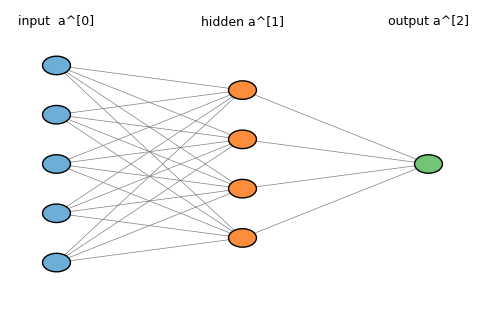

In [ ]:
def draw_nn_diagram(layer_sizes, layer_names=None):
    """Simple circles-and-lines diagram of a fully-connected network."""
    fig, ax = plt.subplots(figsize=(6, 4))
    n_layers = len(layer_sizes)
    x_positions = np.linspace(0.1, 0.9, n_layers)
    max_nodes = max(layer_sizes)

    positions = []
    for li, n_nodes in enumerate(layer_sizes):
        y_positions = np.linspace(0.5 - 0.08*(n_nodes-1), 0.5 + 0.08*(n_nodes-1), n_nodes) if n_nodes > 1 else [0.5]
        positions.append([(x_positions[li], y) for y in y_positions])

    for li in range(n_layers - 1):
        for (x1, y1) in positions[li]:
            for (x2, y2) in positions[li+1]:
                ax.plot([x1, x2], [y1, y2], color="gray", linewidth=0.5, zorder=1)

    colors = ["#6baed6", "#fd8d3c", "#74c476", "#e6550d"]
    for li, layer_pos in enumerate(positions):
        color = colors[min(li, len(colors)-1)]
        for (x, y) in layer_pos:
            circ = patches.Circle((x, y), 0.03, color=color, zorder=2, ec="black")
            ax.add_patch(circ)
        label = layer_names[li] if layer_names else f"layer {li}"
        ax.text(x_positions[li], 0.95, label, ha="center", fontsize=9)

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis("off")
    plt.show()

# A 2-layer network: n_x inputs -> 4 hidden units -> 1 output
draw_nn_diagram([5, 4, 1], layer_names=["input  a^[0]", "hidden a^[1]", "output a^[2]"])

(The diagram above only draws 5 input nodes for clarity — our real network will use all `n_x` features, just imagine more input circles.)

**Shapes that matter, for a hidden layer with $n^{[1]}$ units and $n_x$ input features:**

| Symbol | Shape | Meaning |
|---|---|---|
| $W^{[1]}$ | $(n^{[1]}, n_x)$ | one row per hidden unit, one column per input feature |
| $b^{[1]}$ | $(n^{[1]}, 1)$ | one bias per hidden unit |
| $W^{[2]}$ | $(1, n^{[1]})$ | output unit's weights, one per hidden unit |
| $b^{[2]}$ | $(1, 1)$ | output unit's bias (scalar) |

## 2. Computing a Neural Network's Output (single example)

For one example $x$, the 2-layer network computes, unit by unit in the hidden layer:

$$z^{[1]}_i = w^{[1]T}_i x + b^{[1]}_i, \qquad a^{[1]}_i = g(z^{[1]}_i) \quad \text{for } i = 1, \dots, n^{[1]}$$

then the output:

$$z^{[2]} = w^{[2]T} a^{[1]} + b^{[2]}, \qquad a^{[2]} = \sigma(z^{[2]})$$

Below: an explicit, non-vectorized loop over hidden units (small hand example with 3 features, 4 hidden units), then confirmed against the vectorized matrix version.

In [ ]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def tanh_activation(z):
    return np.tanh(z)

# Small hand example: 3 input features, 4 hidden units
np.random.seed(2)
x_example = np.random.randn(3, 1)
W1_example = np.random.randn(4, 3) * 0.5
b1_example = np.zeros((4, 1))
W2_example = np.random.randn(1, 4) * 0.5
b2_example = np.zeros((1, 1))

# ---- explicit loop over hidden units ----
n_h = 4
a1_loop = np.zeros((n_h, 1))
for i in range(n_h):
    z1_i = 0.0
    for j in range(3):                      # loop over input features
        z1_i += W1_example[i, j] * x_example[j, 0]
    z1_i += b1_example[i, 0]
    a1_loop[i, 0] = tanh_activation(z1_i)

z2_loop = 0.0
for i in range(n_h):
    z2_loop += W2_example[0, i] * a1_loop[i, 0]
z2_loop += b2_example[0, 0]
a2_loop = sigmoid(z2_loop)

print("Loop version -> a1:", a1_loop.ravel(), " a2:", a2_loop)

# ---- vectorized (matrix) version, single example ----
Z1 = np.dot(W1_example, x_example) + b1_example
A1 = tanh_activation(Z1)
Z2 = np.dot(W2_example, A1) + b2_example
A2 = sigmoid(Z2)

print("Matrix version -> a1:", A1.ravel(), " a2:", A2.ravel())

Loop version -> a1: [ 0.54252462  0.78575609 -0.9790617  -0.50274436]  a2: 0.36437226807175693
Matrix version -> a1: [ 0.54252462  0.78575609 -0.9790617  -0.50274436]  a2: [0.36437227]


## 3. Vectorizing Across Multiple Examples

Instead of looping over the `m` training examples one at a time, stack them as **columns** of $X$ (shape `(n_x, m)`) exactly like in logistic regression, and compute all examples at once:

$$Z^{[1]} = W^{[1]} X + b^{[1]}, \qquad A^{[1]} = g(Z^{[1]})$$
$$Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]}, \qquad A^{[2]} = \sigma(Z^{[2]})$$

Every quantity now has an extra dimension for "which example": $Z^{[1]}$ has shape $(n^{[1]}, m)$ — row $i$, column $j$ is the pre-activation of hidden unit $i$ for training example $j$.

In [ ]:
n_h = 4  # number of hidden units, chosen for this demo

np.random.seed(3)
W1 = np.random.randn(n_h, n_x) * 0.01
b1 = np.zeros((n_h, 1))
W2 = np.random.randn(1, n_h) * 0.01
b2 = np.zeros((1, 1))

Z1 = np.dot(W1, X_train) + b1     # (n_h, n_x) @ (n_x, m) -> (n_h, m); b1 broadcasts
A1 = np.tanh(Z1)
Z2 = np.dot(W2, A1) + b2          # (1, n_h) @ (n_h, m) -> (1, m)
A2 = sigmoid(Z2)

print("Z1 shape:", Z1.shape, " (n_h, m) =", (n_h, m))
print("A1 shape:", A1.shape)
print("Z2 shape:", Z2.shape, " (1, m)")
print("A2 shape:", A2.shape, " <- these are the predictions for all", m, "examples at once")

Z1 shape: (4, 436)  (n_h, m) = (4, 436)
A1 shape: (4, 436)
Z2 shape: (1, 436)  (1, m)
A2 shape: (1, 436)  <- these are the predictions for all 436 examples at once


## 4. Explanation For Vectorized Implementation

Why does `np.dot(W1, X_train) + b1` correctly compute *all* examples simultaneously? Because matrix multiplication is defined exactly as "dot product of each row of $W^{[1]}$ with each column of $X$":

$$W^{[1]}X = \begin{bmatrix} w^{[1]T}_1 \\ w^{[1]T}_2 \\ \vdots \end{bmatrix} \begin{bmatrix} x^{(1)} & x^{(2)} & \cdots & x^{(m)} \end{bmatrix} = \begin{bmatrix} w^{[1]T}_1 x^{(1)} & w^{[1]T}_1 x^{(2)} & \cdots \\ w^{[1]T}_2 x^{(1)} & w^{[1]T}_2 x^{(2)} & \cdots \\ \vdots & & \ddots \end{bmatrix}$$

Column $j$ of the result is exactly $W^{[1]}x^{(j)}$ — the hidden layer's pre-activations for training example $j$ alone. So one matrix multiply computes what would otherwise be `m` separate matrix-vector products. `+ b1` then adds the same bias vector to every column via NumPy **broadcasting** (a `(n_h, 1)` array is automatically repeated across all `m` columns).

In [ ]:
# Concrete proof: column j of the vectorized Z1 equals W1 @ (single example j) + b1
j = 5   # pick an arbitrary example
z1_single = np.dot(W1, X_train[:, j:j+1]) + b1     # compute just for example j
z1_from_batch = Z1[:, j:j+1]                        # slice out column j from the batch computation

print("Single-example computation:\n", z1_single.ravel())
print("Same column from batched Z1:\n", z1_from_batch.ravel())
print("Match:", np.allclose(z1_single, z1_from_batch))

Single-example computation:
 [ 0.01658612 -0.02535083  0.01774984  0.04839607]
Same column from batched Z1:
 [ 0.01658612 -0.02535083  0.01774984  0.04839607]
Match: True


## 5. Activation Functions

The activation function $g(z)$ is what's applied after the linear step $z = Wx+b$. Four common choices:

- **Sigmoid** $\sigma(z) = \dfrac{1}{1+e^{-z}}$ — output in $(0,1)$; mainly used at the **output** layer for binary classification probabilities.
- **Tanh** $\tanh(z)$ — output in $(-1,1)$, zero-centered; usually works better than sigmoid in **hidden** layers.
- **ReLU** $\max(0, z)$ — the most common default for hidden layers in modern deep networks; fast to compute, avoids some of the "vanishing gradient" issues below.
- **Leaky ReLU** $\max(0.01z, z)$ — a small fix to ReLU so units don't "die" (get stuck outputting exactly 0 forever).

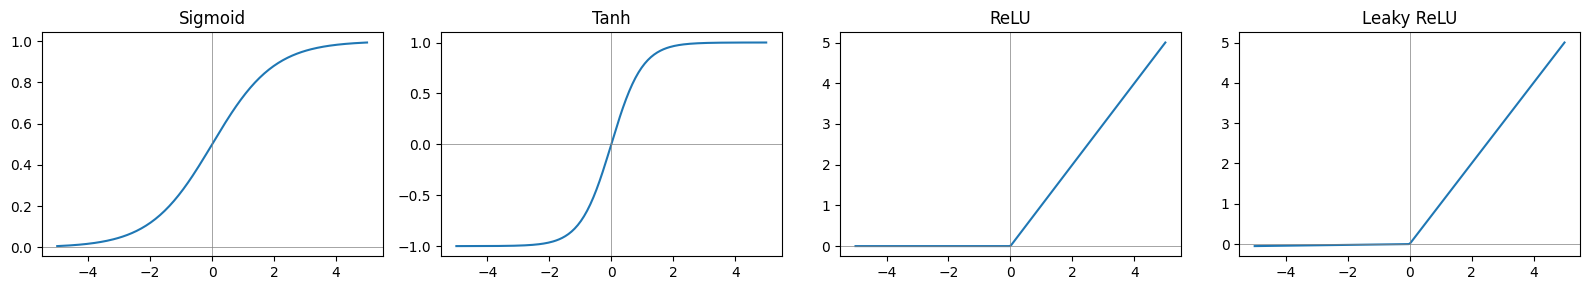

In [ ]:
def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

z_vals = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
funcs = [("Sigmoid", sigmoid), ("Tanh", np.tanh), ("ReLU", relu), ("Leaky ReLU", leaky_relu)]
for ax, (name, fn) in zip(axes, funcs):
    ax.plot(z_vals, fn(z_vals))
    ax.set_title(name)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

## 6. Why Non-linear Activation Functions

If every activation function were **linear** (e.g. $g(z) = z$), stacking layers would be pointless: a linear function of a linear function is still just linear. No matter how many hidden layers you stack, the whole network would collapse into a single logistic-regression-equivalent model, unable to learn curved decision boundaries.

Proof by direct computation below: build a 2-layer network with **linear** activations, and show that its output is mathematically identical to a single-layer (no hidden layer) linear model with an equivalent combined weight and bias.

In [ ]:
# If g(z) = z (identity/linear) everywhere:
# a1 = z1 = W1 x + b1
# a2 = z2 = W2 a1 + b2 = W2 (W1 x + b1) + b2 = (W2 W1) x + (W2 b1 + b2)
# This is just ANOTHER single linear function of x -- call it W_eff, b_eff.

np.random.seed(4)
W1_lin = np.random.randn(4, n_x) * 0.1
b1_lin = np.random.randn(4, 1) * 0.1
W2_lin = np.random.randn(1, 4) * 0.1
b2_lin = np.random.randn(1, 1) * 0.1

# "2-layer" network with purely linear activations
Z1_lin = np.dot(W1_lin, X_train) + b1_lin
A1_lin = Z1_lin                                  # linear activation = identity
Z2_lin = np.dot(W2_lin, A1_lin) + b2_lin         # this is the final output

# Equivalent single-layer linear model
W_eff = np.dot(W2_lin, W1_lin)
b_eff = np.dot(W2_lin, b1_lin) + b2_lin
Z_eff = np.dot(W_eff, X_train) + b_eff

print("Max difference between '2-layer linear' and 'single effective linear' outputs:")
print(np.max(np.abs(Z2_lin - Z_eff)), " (should be ~0 -- they're the same function)")

Max difference between '2-layer linear' and 'single effective linear' outputs:
1.1102230246251565e-16  (should be ~0 -- they're the same function)


This is exactly why hidden layers use **non-linear** activations (tanh, ReLU, etc.) — non-linearity is what lets the network compose simple pieces into genuinely more expressive, curved decision boundaries.

The one place a linear activation is normal is the *output* unit of a **regression** problem (predicting a real number) — but even then, hidden layers must stay non-linear.

## 7. Derivatives Of Activation Functions

Backpropagation needs $g'(z)$ for whichever activation was used. Conveniently, each of these has a simple derivative, usually expressed in terms of the activation's own **output** $a = g(z)$ (cheaper than recomputing from $z$):

- Sigmoid: $g'(z) = a(1-a)$
- Tanh: $g'(z) = 1 - a^2$
- ReLU: $g'(z) = 1$ if $z>0$, else $0$ (undefined exactly at $z=0$, conventionally set to 0 or 1)
- Leaky ReLU: $g'(z) = 1$ if $z>0$, else $0.01$

In [ ]:
def sigmoid_derivative(a):
    return a * (1 - a)

def tanh_derivative(a):
    return 1 - a**2

def relu_derivative(z):
    return (z > 0).astype(float)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1.0, alpha)

# Verify each analytically-derived formula against numerical (finite-difference) derivatives
eps = 1e-6
z_test = np.array([-2.0, -0.5, 0.3, 1.5])

checks = [
    ("sigmoid", sigmoid, lambda z: sigmoid_derivative(sigmoid(z))),
    ("tanh",    np.tanh, lambda z: tanh_derivative(np.tanh(z))),
    ("relu",    relu,    lambda z: relu_derivative(z)),
]

for name, fn, analytic_fn in checks:
    numeric = (fn(z_test + eps) - fn(z_test - eps)) / (2 * eps)
    analytic = analytic_fn(z_test)
    print(f"{name:8s} analytic: {np.round(analytic, 4)}  numeric: {np.round(numeric, 4)}")

sigmoid  analytic: [0.105  0.235  0.2445 0.1491]  numeric: [0.105  0.235  0.2445 0.1491]
tanh     analytic: [0.0707 0.7864 0.9151 0.1807]  numeric: [0.0707 0.7864 0.9151 0.1807]
relu     analytic: [0. 0. 1. 1.]  numeric: [0. 0. 1. 1.]


## 8. Gradient Descent For Neural Networks

For the 2-layer network (tanh hidden layer, sigmoid output, binary cross-entropy cost), gradient descent needs $\dfrac{\partial J}{\partial W^{[1]}}, \dfrac{\partial J}{\partial b^{[1]}}, \dfrac{\partial J}{\partial W^{[2]}}, \dfrac{\partial J}{\partial b^{[2]}}$. The update rule is the same idea as logistic regression, just applied to every parameter matrix:

$$W^{[1]} := W^{[1]} - \alpha\, dW^{[1]}, \quad b^{[1]} := b^{[1]} - \alpha\, db^{[1]}, \quad W^{[2]} := W^{[2]} - \alpha\, dW^{[2]}, \quad b^{[2]} := b^{[2]} - \alpha\, db^{[2]}$$

The gradients themselves (derived via backpropagation, next section):

$$dZ^{[2]} = A^{[2]} - Y$$
$$dW^{[2]} = \frac{1}{m} dZ^{[2]} A^{[1]T}, \qquad db^{[2]} = \frac{1}{m}\sum dZ^{[2]}$$
$$dZ^{[1]} = W^{[2]T} dZ^{[2]} * g'^{[1]}(Z^{[1]}) \quad \text{(element-wise product)}$$
$$dW^{[1]} = \frac{1}{m} dZ^{[1]} X^T, \qquad db^{[1]} = \frac{1}{m}\sum dZ^{[1]} \text{ (row-wise)}$$

iteration 0: cost = 0.6931
iteration 200: cost = 0.3214
iteration 400: cost = 0.2709
iteration 600: cost = 0.2368
iteration 800: cost = 0.2196
iteration 1000: cost = 0.2088
iteration 1200: cost = 0.2007
iteration 1400: cost = 0.1951
iteration 1600: cost = 0.1908
iteration 1800: cost = 0.1876


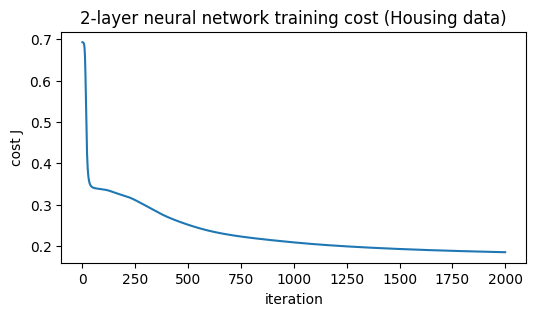

In [ ]:
def compute_cost(A2, Y, eps=1e-8):
    m = Y.shape[1]
    A2c = np.clip(A2, eps, 1 - eps)
    return np.squeeze(-(1.0 / m) * np.sum(Y * np.log(A2c) + (1 - Y) * np.log(1 - A2c)))

def initialize_2layer(n_x, n_h, n_y, scale=0.01, seed=1):
    rng = np.random.RandomState(seed)
    W1 = rng.randn(n_h, n_x) * scale
    b1 = np.zeros((n_h, 1))
    W2 = rng.randn(n_y, n_h) * scale
    b2 = np.zeros((n_y, 1))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

def forward_2layer(X, params):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

def backward_2layer(params, cache, X, Y):
    m = X.shape[1]
    W2 = params["W2"]
    A1, A2 = cache["A1"], cache["A2"]

    dZ2 = A2 - Y
    dW2 = (1.0 / m) * np.dot(dZ2, A1.T)
    db2 = (1.0 / m) * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = np.dot(W2.T, dZ2) * tanh_derivative(A1)
    dW1 = (1.0 / m) * np.dot(dZ1, X.T)
    db1 = (1.0 / m) * np.sum(dZ1, axis=1, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

def update_2layer(params, grads, alpha):
    params["W1"] -= alpha * grads["dW1"]
    params["b1"] -= alpha * grads["db1"]
    params["W2"] -= alpha * grads["dW2"]
    params["b2"] -= alpha * grads["db2"]
    return params

def train_2layer(X, Y, n_h=4, num_iterations=2000, alpha=0.5, print_cost=False, seed=1):
    n_x, n_y = X.shape[0], Y.shape[0]
    params = initialize_2layer(n_x, n_h, n_y, seed=seed)
    costs = []
    for it in range(num_iterations):
        A2, cache = forward_2layer(X, params)
        cost = compute_cost(A2, Y)
        grads = backward_2layer(params, cache, X, Y)
        params = update_2layer(params, grads, alpha)
        costs.append(cost)
        if print_cost and it % 200 == 0:
            print(f"iteration {it}: cost = {cost:.4f}")
    return params, costs

params_2l, costs_2l = train_2layer(X_train, Y_train, n_h=4, num_iterations=2000, alpha=0.5, print_cost=True)

plt.figure(figsize=(6, 3))
plt.plot(costs_2l)
plt.xlabel("iteration"); plt.ylabel("cost J")
plt.title("2-layer neural network training cost (Housing data)")
plt.show()

In [ ]:
def predict_2layer(params, X, threshold=0.5):
    A2, _ = forward_2layer(X, params)
    return (A2 > threshold).astype(int)

train_preds_2l = predict_2layer(params_2l, X_train)
test_preds_2l  = predict_2layer(params_2l, X_test)

print("2-layer NN train accuracy:", round(np.mean(train_preds_2l == Y_train) * 100, 2), "%")
print("2-layer NN test accuracy: ", round(np.mean(test_preds_2l == Y_test) * 100, 2), "%")
print("(compare to the plain logistic regression baseline from the earlier notebook: ~79.8% test accuracy)")

2-layer NN train accuracy: 91.28 %
2-layer NN test accuracy:  80.73 %
(compare to the plain logistic regression baseline from the earlier notebook: ~79.8% test accuracy)


## 9. Backpropagation Intuition

Backpropagation is just the chain rule, walked backwards through the computation graph, layer by layer. For our 2-layer network the forward graph is:

$$X \;\rightarrow\; Z^{[1]} \;\rightarrow\; A^{[1]} \;\rightarrow\; Z^{[2]} \;\rightarrow\; A^{[2]} \;\rightarrow\; J$$

Backprop walks it right to left, at each step using the derivative of the *next* step's output with respect to the *current* step:

$$dA^{[2]} \to dZ^{[2]} \to (dW^{[2]}, db^{[2]}, dA^{[1]}) \to dZ^{[1]} \to (dW^{[1]}, db^{[1]})$$

The trick that makes $dZ^{[2]} = A^{[2]} - Y$ so simple is the same one from logistic regression: the sigmoid-derivative and the cross-entropy-loss-derivative cancel algebraically. Below: numerically verify the full backprop implementation above against finite-difference (numerical) gradients, on real housing data — the strongest possible check that the calculus is right.

In [ ]:
def gradient_check(params, X, Y, epsilon=1e-7, num_checks=6):
    """Compare analytic grads (from backward_2layer) to numerical gradients for a handful of parameters."""
    A2, cache = forward_2layer(X, params)
    grads = backward_2layer(params, cache, X, Y)

    rng = np.random.RandomState(0)
    max_diff = 0.0
    checked = 0
    for name in ["W1", "b1", "W2", "b2"]:
        arr = params[name]
        flat_shape = arr.shape
        for _ in range(num_checks // 4 + 1):
            if checked >= num_checks:
                break
            idx = tuple(rng.randint(0, s) for s in flat_shape)

            orig = arr[idx]
            arr[idx] = orig + epsilon
            A2_plus, _ = forward_2layer(X, params)
            cost_plus = compute_cost(A2_plus, Y)

            arr[idx] = orig - epsilon
            A2_minus, _ = forward_2layer(X, params)
            cost_minus = compute_cost(A2_minus, Y)

            arr[idx] = orig  # restore

            numeric_grad = (cost_plus - cost_minus) / (2 * epsilon)
            analytic_grad = grads["d" + name][idx]
            diff = abs(numeric_grad - analytic_grad)
            max_diff = max(max_diff, diff)
            checked += 1
            print(f"{name}{idx}: analytic={analytic_grad:.6f}  numeric={numeric_grad:.6f}  diff={diff:.2e}")

    print(f"\nMax difference across {checked} checked parameters: {max_diff:.2e} (should be tiny, e.g. < 1e-5)")

params_for_check = initialize_2layer(n_x, 4, 1, seed=7)
gradient_check(params_for_check, X_train, Y_train)

W1(0, 5): analytic=-0.000160  numeric=-0.000160  diff=3.39e-10
W1(0, 3): analytic=-0.000177  numeric=-0.000177  diff=3.23e-10
b1(3, 0): analytic=-0.000036  numeric=-0.000036  diff=7.06e-10
b1(3, 0): analytic=-0.000036  numeric=-0.000036  diff=7.06e-10
W2(0, 3): analytic=-0.000806  numeric=-0.000806  diff=1.31e-10
W2(0, 1): analytic=-0.001009  numeric=-0.001009  diff=8.75e-10

Max difference across 6 checked parameters: 8.75e-10 (should be tiny, e.g. < 1e-5)


## 10. Random Initialization

Why not just initialize $W^{[1]}$ and $W^{[2]}$ to all zeros (like we safely did for logistic regression's single $w$)? For a network with a **hidden layer**, this fails: if every hidden unit starts with identical weights, they receive identical gradients on every update and stay identical forever (the "symmetry" is never broken) — effectively collapsing the whole hidden layer into a single useless unit, no matter how many units it has.

The fix: initialize weights **randomly** (small values), while biases can safely start at zero (they don't cause the symmetry problem).

Hidden layer weights after training with ZERO init (every row should look identical):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

Final cost with zero init: 0.6929
Final cost with random init (from section 8): 0.185


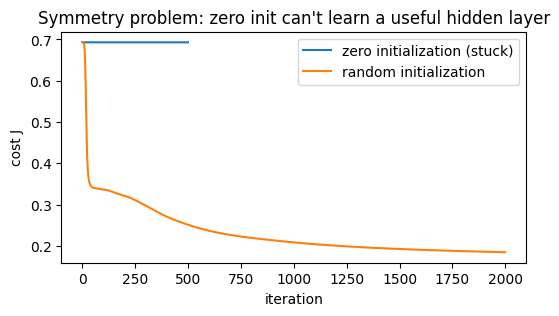

In [ ]:
def initialize_2layer_zero(n_x, n_h, n_y):
    return {
        "W1": np.zeros((n_h, n_x)),
        "b1": np.zeros((n_h, 1)),
        "W2": np.zeros((n_y, n_h)),
        "b2": np.zeros((n_y, 1)),
    }

# Train with all-zero initialization
params_zero = initialize_2layer_zero(n_x, 4, 1)
costs_zero = []
for it in range(500):
    A2, cache = forward_2layer(X_train, params_zero)
    cost = compute_cost(A2, Y_train)
    grads = backward_2layer(params_zero, cache, X_train, Y_train)
    params_zero = update_2layer(params_zero, grads, alpha=0.5)
    costs_zero.append(cost)

print("Hidden layer weights after training with ZERO init (every row should look identical):")
print(np.round(params_zero["W1"], 4))

print("\nFinal cost with zero init:", round(costs_zero[-1], 4))
print("Final cost with random init (from section 8):", round(costs_2l[-1], 4))

plt.figure(figsize=(6, 3))
plt.plot(costs_zero, label="zero initialization (stuck)")
plt.plot(costs_2l, label="random initialization")
plt.xlabel("iteration"); plt.ylabel("cost J")
plt.legend()
plt.title("Symmetry problem: zero init can't learn a useful hidden layer")
plt.show()

## 11. Deep L-Layer Neural Network

Everything above generalizes from "1 hidden layer" to **L layers** by describing the network as a list of layer sizes, e.g. `layer_dims = [n_x, 8, 4, 1]` means: input with `n_x` features, hidden layer 1 with 8 units, hidden layer 2 with 4 units, output layer with 1 unit (`L=3` layers total, not counting the input).

Parameters become a **dictionary** indexed by layer number, since the number of layers is no longer fixed at 2:

$$W^{[l]} \text{ shape } (n^{[l]}, n^{[l-1]}), \qquad b^{[l]} \text{ shape } (n^{[l]}, 1) \quad \text{for } l = 1, \dots, L$$

Random initialization generalizes the same way — every $W^{[l]}$ gets small random values, every $b^{[l]}$ starts at zero.

In [ ]:
def initialize_parameters_deep(layer_dims, seed=1):
    """layer_dims: list like [n_x, n_h1, n_h2, ..., n_y]"""
    rng = np.random.RandomState(seed)
    parameters = {}
    L = len(layer_dims) - 1   # number of layers (excluding input)
    for l in range(1, L + 1):
        parameters[f"W{l}"] = rng.randn(layer_dims[l], layer_dims[l-1]) * 0.01
        parameters[f"b{l}"] = np.zeros((layer_dims[l], 1))
    return parameters

layer_dims_example = [n_x, 8, 4, 1]
params_deep_demo = initialize_parameters_deep(layer_dims_example)
for key in sorted(params_deep_demo.keys()):
    print(key, params_deep_demo[key].shape)

W1 (8, 13)
W2 (4, 8)
W3 (1, 4)
b1 (8, 1)
b2 (4, 1)
b3 (1, 1)


## 12. Forward and Backward Propagation (generic building blocks)

Rather than writing separate code for every possible depth, define two small, reusable functions and call them in a loop over layers — this is exactly how real frameworks are structured internally:

**Forward, per layer:** `linear_forward` computes $Z^{[l]} = W^{[l]}A^{[l-1]} + b^{[l]}$, then `activation_forward` applies $g^{[l]}$ to get $A^{[l]}$. Hidden layers use ReLU; the final layer uses sigmoid (for binary classification).

**Backward, per layer:** the mirror image — `activation_backward` converts $dA^{[l]} \to dZ^{[l]}$ using $g^{[l]\prime}$, then `linear_backward` converts $dZ^{[l]} \to (dW^{[l]}, db^{[l]}, dA^{[l-1]})$, which becomes the input to the previous layer's backward step. Each layer only needs to know its own local derivative — that's what makes arbitrary depth possible.

In [ ]:
def linear_forward(A_prev, W, b):
    Z = np.dot(W, A_prev) + b
    cache = (A_prev, W, b)
    return Z, cache

def activation_forward(A_prev, W, b, activation):
    Z, linear_cache = linear_forward(A_prev, W, b)
    if activation == "relu":
        A = relu(Z)
    elif activation == "sigmoid":
        A = sigmoid(Z)
    else:
        raise ValueError("unknown activation")
    cache = (linear_cache, Z)
    return A, cache

def linear_backward(dZ, linear_cache):
    A_prev, W, b = linear_cache
    m = A_prev.shape[1]
    dW = (1.0 / m) * np.dot(dZ, A_prev.T)
    db = (1.0 / m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)
    return dA_prev, dW, db

def activation_backward(dA, cache, activation):
    linear_cache, Z = cache
    if activation == "relu":
        dZ = dA * relu_derivative(Z)
    elif activation == "sigmoid":
        A = sigmoid(Z)
        dZ = dA * sigmoid_derivative(A)
    else:
        raise ValueError("unknown activation")
    dA_prev, dW, db = linear_backward(dZ, linear_cache)
    return dA_prev, dW, db

print("Generic forward/backward building blocks defined.")

Generic forward/backward building blocks defined.


## 13. Forward Propagation in a Deep Network

Chain `activation_forward` calls across all `L` layers: ReLU for layers `1..L-1`, sigmoid for the final layer `L`. `caches` stores everything each layer's backward pass will need, so the backward pass never has to recompute anything from scratch.

In [ ]:
def L_model_forward(X, parameters):
    caches = []
    A = X
    L = len(parameters) // 2   # each layer contributes a W and a b

    for l in range(1, L):      # hidden layers: ReLU
        A_prev = A
        A, cache = activation_forward(A_prev, parameters[f"W{l}"], parameters[f"b{l}"], activation="relu")
        caches.append(cache)

    AL, cache = activation_forward(A, parameters[f"W{L}"], parameters[f"b{L}"], activation="sigmoid")
    caches.append(cache)

    return AL, caches

AL_demo, caches_demo = L_model_forward(X_train, params_deep_demo)
print("Final AL shape:", AL_demo.shape, " (should be (1, m) =", (1, m), ")")
print("Number of cached layers:", len(caches_demo), " (should equal L =", len(params_deep_demo)//2, ")")
print("First 5 raw predictions (random init, not yet trained):", AL_demo[0, :5])

Final AL shape: (1, 436)  (should be (1, m) = (1, 436) )
Number of cached layers: 3  (should equal L = 3 )
First 5 raw predictions (random init, not yet trained): [0.50000263 0.500003   0.50000182 0.49999737 0.50000063]


And the matching full backward pass + parameter update, so the deep network can actually be trained end to end:

iteration 0: cost = 0.6931
iteration 200: cost = 0.6929
iteration 400: cost = 0.6929
iteration 600: cost = 0.6929
iteration 800: cost = 0.6929
iteration 1000: cost = 0.6929
iteration 1200: cost = 0.6928
iteration 1400: cost = 0.6924
iteration 1600: cost = 0.6822
iteration 1800: cost = 0.3333


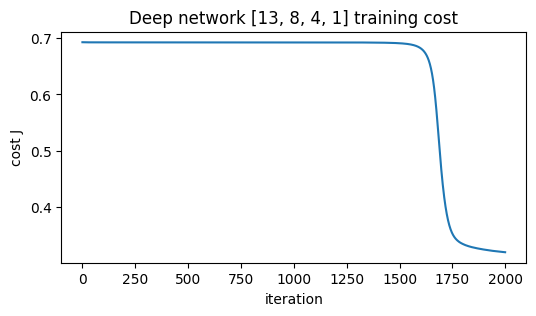

In [ ]:
def L_model_backward(AL, Y, caches):
    grads = {}
    L = len(caches)
    m = AL.shape[1]
    Y = Y.reshape(AL.shape)

    # derivative of cost w.r.t. AL (cross-entropy), then step through the output (sigmoid) layer
    dAL = -(np.divide(Y, np.clip(AL, 1e-8, 1)) - np.divide(1 - Y, np.clip(1 - AL, 1e-8, 1)))

    current_cache = caches[L - 1]
    dA_prev, dW, db = activation_backward(dAL, current_cache, activation="sigmoid")
    grads[f"dW{L}"] = dW
    grads[f"db{L}"] = db

    for l in reversed(range(1, L)):    # hidden layers, backwards
        current_cache = caches[l - 1]
        dA_prev, dW, db = activation_backward(dA_prev, current_cache, activation="relu")
        grads[f"dW{l}"] = dW
        grads[f"db{l}"] = db

    return grads

def update_parameters_deep(parameters, grads, alpha):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters[f"W{l}"] -= alpha * grads[f"dW{l}"]
        parameters[f"b{l}"] -= alpha * grads[f"db{l}"]
    return parameters

def train_deep_model(X, Y, layer_dims, num_iterations=2000, alpha=0.1, seed=1, print_cost=False):
    parameters = initialize_parameters_deep(layer_dims, seed=seed)
    costs = []
    for it in range(num_iterations):
        AL, caches = L_model_forward(X, parameters)
        cost = compute_cost(AL, Y)
        grads = L_model_backward(AL, Y, caches)
        parameters = update_parameters_deep(parameters, grads, alpha)
        costs.append(cost)
        if print_cost and it % 200 == 0:
            print(f"iteration {it}: cost = {cost:.4f}")
    return parameters, costs

deep_layer_dims = [n_x, 8, 4, 1]   # 3-layer network: n_x -> 8 -> 4 -> 1
params_deep, costs_deep = train_deep_model(X_train, Y_train, deep_layer_dims,
                                             num_iterations=2000, alpha=0.1, print_cost=True)

plt.figure(figsize=(6, 3))
plt.plot(costs_deep)
plt.xlabel("iteration"); plt.ylabel("cost J")
plt.title(f"Deep network {deep_layer_dims} training cost")
plt.show()

In [ ]:
def predict_deep(parameters, X, threshold=0.5):
    AL, _ = L_model_forward(X, parameters)
    return (AL > threshold).astype(int)

train_preds_deep = predict_deep(params_deep, X_train)
test_preds_deep  = predict_deep(params_deep, X_test)

print("Deep network train accuracy:", round(np.mean(train_preds_deep == Y_train) * 100, 2), "%")
print("Deep network test accuracy: ", round(np.mean(test_preds_deep == Y_test) * 100, 2), "%")
print()
print("Summary so far on this dataset:")
print("  Logistic regression   test accuracy: ~79.8%")
print("  2-layer NN (4 hidden)  test accuracy:", round(np.mean(test_preds_2l == Y_test) * 100, 2), "%")
print("  Deep NN", deep_layer_dims, "test accuracy:", round(np.mean(test_preds_deep == Y_test) * 100, 2), "%")

Deep network train accuracy: 86.01 %
Deep network test accuracy:  78.9 %

Summary so far on this dataset:
  Logistic regression   test accuracy: ~79.8%
  2-layer NN (4 hidden)  test accuracy: 80.73 %
  Deep NN [13, 8, 4, 1] test accuracy: 78.9 %


## 14. Getting Matrix Dimensions Right

The single most common bug when building a network by hand is a shape mismatch. A quick habit: for any `layer_dims`, write out every parameter and activation shape *before* writing the training loop, and assert them as the network runs. Below is a small utility that prints the expected shape table for any `layer_dims`, and a live sanity-check against the actual arrays produced by a forward pass.

In [ ]:
def print_dimension_table(layer_dims, m):
    print(f"{'layer':>6} | {'W shape':>14} | {'b shape':>10} | {'Z / A shape':>12}")
    print("-" * 52)
    print(f"{'0 (X)':>6} | {'':>14} | {'':>10} | {(layer_dims[0], m)!s:>12}")
    for l in range(1, len(layer_dims)):
        w_shape = (layer_dims[l], layer_dims[l-1])
        b_shape = (layer_dims[l], 1)
        za_shape = (layer_dims[l], m)
        print(f"{l:>6} | {str(w_shape):>14} | {str(b_shape):>10} | {str(za_shape):>12}")

print_dimension_table(deep_layer_dims, m)

 layer |        W shape |    b shape |  Z / A shape
----------------------------------------------------
 0 (X) |                |            |    (13, 436)
     1 |        (8, 13) |     (8, 1) |     (8, 436)
     2 |         (4, 8) |     (4, 1) |     (4, 436)
     3 |         (1, 4) |     (1, 1) |     (1, 436)


In [ ]:
# Live sanity check: confirm every actual array in the trained deep network matches the table above
L = len(deep_layer_dims) - 1
for l in range(1, L + 1):
    expected_W = (deep_layer_dims[l], deep_layer_dims[l-1])
    expected_b = (deep_layer_dims[l], 1)
    actual_W = params_deep[f"W{l}"].shape
    actual_b = params_deep[f"b{l}"].shape
    status_W = "OK" if actual_W == expected_W else "MISMATCH"
    status_b = "OK" if actual_b == expected_b else "MISMATCH"
    print(f"W{l}: expected {expected_W}, got {actual_W}  [{status_W}]")
    print(f"b{l}: expected {expected_b}, got {actual_b}  [{status_b}]")

# Deliberately trigger a dimension error, to see what it looks like and why it happens
print("\nDeliberately mismatched multiply (W1 has n_x columns, but here we feed it only 3 rows of X):")
try:
    bad = np.dot(params_deep["W1"], X_train[:3, :])
except ValueError as e:
    print("ValueError:", e)
    print("-> W1 expects", params_deep['W1'].shape[1], "input features per example, but only 3 were given.")

W1: expected (8, 13), got (8, 13)  [OK]
b1: expected (8, 1), got (8, 1)  [OK]
W2: expected (4, 8), got (4, 8)  [OK]
b2: expected (4, 1), got (4, 1)  [OK]
W3: expected (1, 4), got (1, 4)  [OK]
b3: expected (1, 1), got (1, 1)  [OK]

Deliberately mismatched multiply (W1 has n_x columns, but here we feed it only 3 rows of X):
ValueError: shapes (8,13) and (3,436) not aligned: 13 (dim 1) != 3 (dim 0)
-> W1 expects 13 input features per example, but only 3 were given.
